In [1]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
import matplotlib as mpl
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns
import pandas as pd
import os

### TODO: input results paths

In [2]:
# RL model path 
model_parameter_0 = "PPO_Tue Jul  9 17:19:57 2024"
model_parameter_1 = "PPO_Tue Jul  9 17:46:24 2024"
model_parameter_2 = "PPO_Tue Jul  9 17:55:41 2024"

# Evaluate RL step length
model_step_parameter = 38400

# RL base path
base_path_0 = "../results/RL_MFD_normal/"+str(model_parameter_0)+"/test_"+str(model_step_parameter)+"/" 
base_path_1 = "../results/RL_MFD_normal/"+str(model_parameter_1)+"/test_"+str(model_step_parameter)+"/" 
base_path_2 = "../results/RL_MFD_normal/"+str(model_parameter_2)+"/test_"+str(model_step_parameter)+"/" 

# BO results path 
base_path_BO = "../output/BO_new_MDP/MFD_pt_60_changed_ratio/"

# No Toll results path 
base_path_NT = "../output/MFD/capacity/7000/NT/"

numOfusers = int(7500)

plot_path = "../Plot/Benchmark/"
# plot_path = "../Plot/RL_MFD_normal/fftt_rw/eval_comparison/"
if not os.path.exists(plot_path):
    os.makedirs(plot_path)

In [3]:
# Plot set
custom_palette = sns.color_palette("Set2", n_colors=3)
dpi = 300
plt.rcParams["font.family"] = "Times New Roman"
hyperparameter_name = "Benchmark"
plt.style.use('default')  # This will reset any style settings to default

In [4]:
toll_arr_0 = np.load(file=(base_path_0+"toll.npy"))
tt_arr_0 = np.load(file=(base_path_0+"tt.npy"))
action_arr_0 = np.load(file=(base_path_0+"action.npy"))
mp_arr_0 = np.load(file=(base_path_0+"mp.npy"))
rw_arr_0 = np.load(file=(base_path_0+"rw.npy"))
sw_arr_0 = np.load(file=(base_path_0+"sw.npy"))
pt_arr_0 = np.load(file=(base_path_0+"pt.npy"))
car_only_tt_arr_0 = (numOfusers * tt_arr_0[-1,0,:] - 60 * pt_arr_0[-1,0,:])/(numOfusers - pt_arr_0[-1,0,:])
print("mp_arr_0.shape: ", mp_arr_0.shape)

toll_arr_1 = np.load(file=(base_path_1+"toll.npy"))
tt_arr_1 = np.load(file=(base_path_1+"tt.npy"))
action_arr_1 = np.load(file=(base_path_1+"action.npy"))
mp_arr_1 = np.load(file=(base_path_1+"mp.npy"))
rw_arr_1 = np.load(file=(base_path_1+"rw.npy"))
sw_arr_1 = np.load(file=(base_path_1+"sw.npy"))
pt_arr_1 = np.load(file=(base_path_1+"pt.npy"))
car_only_tt_arr_1 = (numOfusers * tt_arr_1[-1,0,:] - 60 * pt_arr_1[-1,0,:])/(numOfusers - pt_arr_1[-1,0,:])
print("mp_arr_1.shape: ", mp_arr_1.shape)


toll_arr_2 = np.load(file=(base_path_2+"toll.npy"))
tt_arr_2 = np.load(file=(base_path_2+"tt.npy"))
action_arr_2 = np.load(file=(base_path_2+"action.npy"))
mp_arr_2 = np.load(file=(base_path_2+"mp.npy"))
rw_arr_2 = np.load(file=(base_path_2+"rw.npy"))
sw_arr_2 = np.load(file=(base_path_2+"sw.npy"))
pt_arr_2 = np.load(file=(base_path_2+"pt.npy"))
car_only_tt_arr_2 = (numOfusers * tt_arr_2[-1,0,:] - 60 * pt_arr_2[-1,0,:])/(numOfusers - pt_arr_2[-1,0,:])
print("mp_arr_2.shape: ", mp_arr_2.shape)


mp_arr_0.shape:  (1, 1, 61)
mp_arr_1.shape:  (1, 1, 61)
mp_arr_2.shape:  (1, 1, 61)


In [5]:
optimal_toll = np.load(base_path_BO+"optimal_toll.npy")
optimal_Travel_tt = np.load(base_path_BO+"optimal_y.npy")
tt_array_epiode_BO = np.load(base_path_BO+"y_value_all_eps.npy")
flow_arr_BO = np.load(base_path_BO+"flow_record_array.npy")
toll_arr_BO = np.load(base_path_BO+"toll_record.npy")
sw_arr_BO = np.load(base_path_BO+"sw_all_eps.npy")
pt_arr_BO = np.load(base_path_BO+"pt_all_eps.npy")
mp_arr_BO = np.load(base_path_BO+"mp_all_eps.npy")
convergence_array = np.load(base_path_BO+"convergence_all_eps.npy")
min_index = np.argmin(tt_array_epiode_BO)
a = flow_arr_BO[min_index, -6:, :, :]
b = a[a[:, : , 0]!=-1]
tt_arr_BO = []
car_only_tt_arr_BO = []
rw_arr_BO = []
for i in range(60):
    tt_arr_BO.append(np.mean(flow_arr_BO[min_index, i:i+1, :, -1]))
    tmp_1 = flow_arr_BO[min_index, i:i+1, :, :]
    tmp_2 = tmp_1[tmp_1[:, : , 0]!=-1]
    # print(tmp_2.shape)
    car_only_tt_arr_BO.append(np.mean(tmp_2[:, -1]))

rw_arr_BO = []
for i in range(60):
    rw = -tt_arr_BO[i]/24
    pt_share_number = pt_arr_BO[min_index][i]
    if pt_share_number > numOfusers/10:
        pt_reward = - (pt_share_number - numOfusers/10 )/numOfusers
    else:
        pt_reward = - (numOfusers/10 - pt_share_number)/numOfusers
    rw += pt_reward
    rw_arr_BO.append(rw/50)
     
print("mean AITT", np.mean(flow_arr_BO[min_index,:, :, -1]))

print(" last 6 day mean AITT", np.mean(a[:,:,-1]))
print(" last 6 day mean car-only AITT", np.mean(b[:,-1]))
print(" last 6 day sw", np.mean(sw_arr_BO[min_index, -6:]/numOfusers))
print(" last 6 day PT user number", np.mean(pt_arr_BO[min_index, -6:]))
print(" last 6 day mp", np.mean(mp_arr_BO[min_index, -6:]))

print(" tt_array.shape ", tt_array_epiode_BO.shape)
print(" toll_array.shape ", toll_arr_BO.shape)

optimal_toll_parameters = np.array(toll_arr_BO[min_index])
                
print(" optimal_toll ",optimal_toll)
print(" optimal_toll_parameters ", optimal_toll_parameters)
print(" optimal_Travel_tt ",optimal_Travel_tt)
print(" optimal_toll ",optimal_toll)
print(" optimal_toll_parameters ", optimal_toll_parameters)
print(" optimal_Travel_tt ",optimal_Travel_tt)

mean AITT 35.32076917553454
 last 6 day mean AITT 35.378746562611994
 last 6 day mean car-only AITT 32.63899825449548
 last 6 day sw 14.593016775734798
 last 6 day PT user number 751.0
 last 6 day mp 1.1500000000000001
 tt_array.shape  (200,)
 toll_array.shape  (200, 3)
 optimal_toll  [  3.6476442  443.22244504  53.09425332]
 optimal_toll_parameters  [  3.6476442  443.22244504  53.09425332]
 optimal_Travel_tt  1.474233781186645
 optimal_toll  [  3.6476442  443.22244504  53.09425332]
 optimal_toll_parameters  [  3.6476442  443.22244504  53.09425332]
 optimal_Travel_tt  1.474233781186645


In [6]:
tt_arr_NT = np.load(file=(base_path_NT+"ttvec.npy"))
flow = pd.read_csv((base_path_NT+"flowdf.csv"))
flowdf = pd.read_csv((base_path_NT+"flowdf.csv"))
car_only_tt_arr_NT = [] 
tmp = flow[:numOfusers*60]
for i in range(0, 60):
    a= tmp[i*numOfusers:(i+1)*numOfusers]
    mean_Car = np.mean(a[a["departure"]!=-1]["tt"])
    car_only_tt_arr_NT.append(mean_Car)

mp_arr_NT = np.load(file=(base_path_NT+"pricevec.npy"))
sw_arr_NT = np.load(file=(base_path_NT+"swvec.npy"))
pt_arr_NT = np.load(file=(base_path_NT+"ptsharevec.npy"))

rw_arr_NT = []
for i in range(60):
    rw = -tt_arr_NT[i]/24
    pt_share_number = pt_arr_NT[i]
    if pt_share_number > numOfusers/10:
        pt_reward = - (pt_share_number - numOfusers/10 )/numOfusers
    else:
        pt_reward = - (numOfusers/10 - pt_share_number)/numOfusers
    rw += pt_reward
    rw_arr_NT.append(rw/50)
                     
                     
a = flowdf.iloc[-numOfusers*6:]
b = a[a["departure"]!=-1]
print(" mean AITT", np.mean(flowdf.iloc[:, 4]))

print(" last 6 day mean AITT", np.mean(flowdf.iloc[-numOfusers*6:, 4]))
print(" last 6 day mean car-only AITT", np.mean(np.mean(b["tt"])))
print(" first day mean AITT", np.mean(flowdf.iloc[:numOfusers, 4]))
print(" last day mean AITT", np.mean(flowdf.iloc[-numOfusers:, 4]))
print(" last 6 day sw", np.mean(sw_arr_NT[-6:]/numOfusers))
print(" last 6 day PT user number", np.mean(pt_arr_NT[-6:]/7500))
print(" last 6 day price", np.round(np.mean(mp_arr_NT[-6:]),2 ))

 mean AITT 62.745360311399295
 last 6 day mean AITT 62.033629269018064
 last 6 day mean car-only AITT 62.284577404843425
 first day mean AITT 55.19357170252805
 last day mean AITT 62.031958488960456
 last 6 day sw 266.55776480149626
 last 6 day PT user number 0.10984444444444445
 last 6 day price 1.0


In [7]:
font_size = 18
legend_size = 14
subplot_font_size = 20
tick_font_size = 16

# Define the plot_rw_data function to work with an axis passed as parameter
def plot_rw_data(ax, x, rw_mean_0, rw_std_0, rw_arr_NT, rw_arr_BO, ylabel_text="Reward", show_legend=False, labelpad=None, y_limits=None):
    # Colors for the plot
    color_rl = "#fea443"  # Muted orange
    color_nt = "#b3573f"  # Brown for NT
    color_bo = "#435699"  # Blue for BO

    # Plot RL with standard deviation as shaded area
    ax.plot(x, rw_mean_0, color=color_rl, linestyle='--', label='RL', linewidth=2.5)
    ax.fill_between(x, rw_mean_0 - rw_std_0, rw_mean_0 + rw_std_0, color=color_rl, alpha=0.15)
    
    # Plot NT if available
    if rw_arr_NT is not None:
        ax.plot(rw_arr_NT, color=color_nt, linestyle='-', label='NT', linewidth=2.5)

    # Plot BO
    ax.plot(rw_arr_BO, color=color_bo, linestyle='-', label='BO', linewidth=2.5)
    
    # Set labels, ticks, and legend with larger font sizes and a fixed labelpad
    ax.set_xlabel("Day", fontsize=font_size, color='black',  labelpad=0)
    ax.set_ylabel(ylabel_text, fontsize=font_size, color='black', labelpad=labelpad)  # Apply labelpad if provided
    ax.tick_params(axis='both', labelsize=tick_font_size, colors='black')

    # Set y-axis limits if provided
    if y_limits:
        ax.set_ylim(y_limits)
    # Show legend if specified
    if show_legend:
        ax.legend(fontsize=legend_size, title_fontsize=font_size, loc="upper right")

    # Grid
    ax.grid(True, linestyle='--', alpha=0.4)



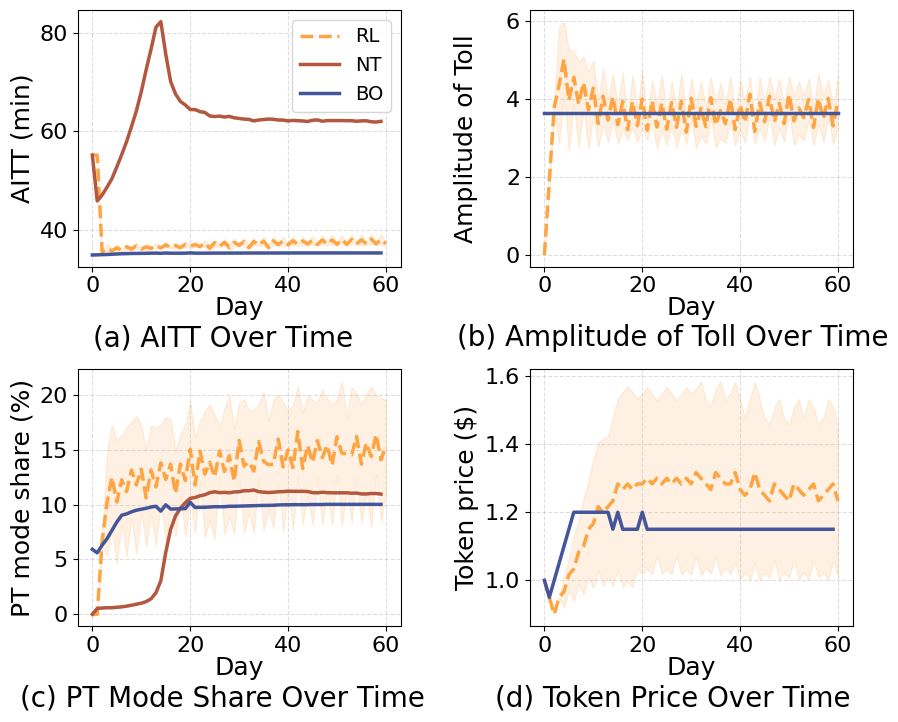

In [8]:
# Define x-axis values
x = list(range(61))

# Sample data for each plot (replace these with your actual data)
rw_std_aitt = np.std([tt_arr_0[-1, 0, :], tt_arr_1[-1, 0, :], tt_arr_2[-1, 0, :]], axis=0)
rw_mean_aitt = np.mean([tt_arr_0[-1, 0, :], tt_arr_1[-1, 0, :], tt_arr_2[-1, 0, :]], axis=0)
rw_arr_NT_aitt = tt_arr_NT
rw_arr_BO_aitt = tt_arr_BO

rw_std_toll = np.std([toll_arr_0[-1, 0, :, 0], toll_arr_1[-1, 0, :, 0], toll_arr_2[-1, 0, :, 0]], axis=0)
rw_mean_toll = np.mean([toll_arr_0[-1, 0, :, 0], toll_arr_1[-1, 0, :, 0], toll_arr_2[-1, 0, :, 0]], axis=0)
rw_arr_BO_toll = np.repeat(optimal_toll_parameters[0], 61)

# Convert PT mode share data to percentages
rw_std_pt = np.std([pt_arr_0[-1, 0, :], pt_arr_1[-1, 0, :], pt_arr_2[-1, 0, :]], axis=0) / 7500 * 100
rw_mean_pt = np.mean([pt_arr_0[-1, 0, :], pt_arr_1[-1, 0, :], pt_arr_2[-1, 0, :]], axis=0) / 7500 * 100
rw_arr_NT_pt = pt_arr_NT / 7500 * 100
rw_arr_BO_pt = pt_arr_BO[min_index, :] / 7500 * 100

rw_std_token = np.std([mp_arr_0[-1, 0, :], mp_arr_1[-1, 0, :], mp_arr_2[-1, 0, :]], axis=0)
rw_mean_token = np.mean([mp_arr_0[-1, 0, :], mp_arr_1[-1, 0, :], mp_arr_2[-1, 0, :]], axis=0)
rw_arr_BO_token = mp_arr_BO[min_index, :]

# Create 2x2 subplots with constrained_layout to handle spacing automatically
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
plt.subplots_adjust(wspace=0.4, hspace=0.4)  # Increase spacing between plots

# Plot AITT with legend
plot_rw_data(
    axs[0, 0],
    x,
    rw_mean_aitt, 
    rw_std_aitt,
    rw_arr_NT=rw_arr_NT_aitt,
    rw_arr_BO=rw_arr_BO_aitt,
    ylabel_text="AITT (min)",
    show_legend=True,
)

# Plot Toll Amplitude with legend
plot_rw_data(
    axs[0, 1],
    x,
    rw_mean_toll, 
    rw_std_toll,
    rw_arr_NT=None,  # NT not available for Toll
    rw_arr_BO=rw_arr_BO_toll,
    ylabel_text="Amplitude of Toll",
    y_limits = None,
    labelpad = 20
)


# Plot PT Mode Share in percentage format
plot_rw_data(
    axs[1, 0],
    x,
    rw_mean_pt, 
    rw_std_pt,
    rw_arr_NT=rw_arr_NT_pt,
    rw_arr_BO=rw_arr_BO_pt,
    ylabel_text="PT mode share (%)",  # Updated label to show percentage
    y_limits = None
)


# Plot Token Price without legend
plot_rw_data(
    axs[1, 1],
    x,
    rw_mean_token, 
    rw_std_token,
    rw_arr_NT=None,  # NT not available for Token Price
    rw_arr_BO=rw_arr_BO_token,
    ylabel_text="Token price ($)",
    y_limits = None,
)
# Add captions below each subplot using fig.text, adjusting coordinates for better alignment
fig.text(0.27, 0.46, "(a) AITT Over Time", ha='center', fontsize=subplot_font_size)
fig.text(0.72, 0.46, "(b) Amplitude of Toll Over Time", ha='center', fontsize=subplot_font_size)
fig.text(0.27, 0.01, "(c) PT Mode Share Over Time", ha='center', fontsize=subplot_font_size)
fig.text(0.72, 0.01, "(d) Token Price Over Time", ha='center', fontsize=subplot_font_size)

# Save the figure with all subplots
plt.savefig(plot_path+"Benchmark.jpeg", dpi=1200)
plt.show()
